In [2]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
#from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import load_properties_bundle, create_folder
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
#from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [3]:
results_folder = "../results/study"
create_folder(results_folder)

In [8]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df = df[df['N_samples']==df['N_samples_perc']]
df

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
26,bond,2,8192,0.071983,0.01,1,1.000,0.6,0.1,1,20,20,0.500434,0.000007,32747.35,1187.871179,1.752333e+07,8.124360e+05
34,bond,2,8192,0.083814,0.01,1,1.000,0.6,0.1,1,20,20,0.500344,0.000007,30685.10,915.258905,1.888285e+07,7.447281e+05
38,bond,2,8192,0.089729,0.01,1,1.000,0.6,0.1,1,20,20,0.500352,0.000007,30231.50,873.029904,1.944677e+07,1.145008e+06
42,bond,2,8192,0.095644,0.01,1,1.000,0.6,0.1,1,20,20,0.500401,0.000006,27421.10,461.432112,1.884806e+07,7.013492e+05
46,bond,2,8192,0.101559,0.01,1,1.000,0.6,0.1,1,20,20,0.500453,0.000006,28919.35,483.353947,2.127903e+07,6.496668e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34261,bond,3,768,0.275083,0.50,8,0.125,0.6,0.1,6,12,12,1.000000,0.000000,767.00,0.000000,1.604659e+05,8.012487e+03
34262,bond,3,768,0.275083,0.50,8,0.125,0.6,0.1,7,12,12,1.000000,0.000000,767.00,0.000000,1.481148e+05,5.042102e+03
34263,bond,3,768,0.275083,0.50,8,0.125,0.6,0.1,8,12,12,1.000000,0.000000,767.00,0.000000,1.699325e+05,1.220308e+04
34264,node,3,16,0.060000,0.01,1,1.000,1.0,0.1,1,3,3,0.993478,0.000044,15.00,0.000000,3.385000e+03,2.487971e+01


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def power_law_offset(x, A, B, beta):
    return A + B * x**beta


def fit_power_law_offset(x, y, p0=None, bounds=(-np.inf, np.inf), plot=True):
    """
    Ajusta o modelo:
        y_fit = A + B*x^beta

    Parâmetros
    ----------
    x, y : array-like
        Dados a serem ajustados.
    p0 : tuple ou list, opcional
        Chute inicial para (A, B, beta).
    bounds : tuple, opcional
        Limites para os parâmetros no formato usado por curve_fit.
    plot : bool
        Se True, plota os dados e o ajuste.

    Retorna
    -------
    result : dict
        Dicionário com parâmetros ajustados, erros e qualidade do ajuste.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Remove NaN e inf
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Para beta não inteiro, x precisa ser positivo
    if np.any(x <= 0):
        raise ValueError("O modelo x^beta com beta real exige x > 0.")

    # Ordena os dados por x
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    # Chute inicial automático, se não for fornecido
    if p0 is None:
        A0 = y[-1]              # bom chute se y tende a um platô
        B0 = y[0] - A0
        beta0 = -1.0            # útil para convergência assintótica
        p0 = (A0, B0, beta0)

    popt, pcov = curve_fit(
        power_law_offset,
        x,
        y,
        p0=p0,
        bounds=bounds,
        maxfev=100000
    )

    A, B, beta = popt
    perr = np.sqrt(np.diag(pcov))

    y_fit = power_law_offset(x, A, B, beta)

    residuals = y - y_fit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot

    result = {
        "A": A,
        "B": B,
        "beta": beta,
        "A_err": perr[0],
        "B_err": perr[1],
        "beta_err": perr[2],
        "r2": r2,
        "x_fit": x,
        "y_fit": y_fit,
        "covariance": pcov
    }

    if plot:
        plt.figure(figsize=(8, 6))

        plt.plot(x, y, "o", label="data")
        plt.plot(
            x,
            y_fit,
            "-",
            label=rf"$A + Bx^\beta$, $\beta={beta:.4f}$"
        )

        plt.xlabel(r"$x$")
        plt.ylabel(r"$y$")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def model_power(x, A, B, beta):
    return A + B * x**beta


def model_quadratic(x, A, B, C):
    return A + B*x + C*x**2


def model_exponential(x, A, B, C):
    return A + B * (np.exp(C*x) - 1)


def calc_metrics(y, yfit, n_params):
    residuals = y - yfit
    rss = np.sum(residuals**2)
    n = len(y)

    rmse = np.sqrt(rss / n)

    # AIC para erro gaussiano com variância desconhecida
    aic = n * np.log(rss / n) + 2 * n_params

    # AIC corrigido para amostra pequena
    aicc = aic + (2 * n_params * (n_params + 1)) / (n - n_params - 1)

    return rss, rmse, aic, aicc


def compare_fits(x, y, ns):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    results = {}

    # -------------------------
    # Modelo 1: A + B x^beta
    # -------------------------
    popt_power, pcov_power = curve_fit(
        model_power,
        x,
        y,
        p0=(y.min(), y.max() - y.min(), 2.0),
        bounds=([-np.inf, -np.inf, 0.0], [np.inf, np.inf, np.inf]),
        maxfev=100000
    )

    yfit_power = model_power(x, *popt_power)
    results["power"] = {
        "params": popt_power,
        "errors": np.sqrt(np.diag(pcov_power)),
        "yfit": yfit_power,
        "metrics": calc_metrics(y, yfit_power, 3)
    }

    # -------------------------
    # Modelo 2: A + B x + C x^2
    # -------------------------
    popt_quad, pcov_quad = curve_fit(
        model_quadratic,
        x,
        y,
        p0=(y.min(), 0.0, 1.0),
        maxfev=100000
    )

    yfit_quad = model_quadratic(x, *popt_quad)
    results["quadratic"] = {
        "params": popt_quad,
        "errors": np.sqrt(np.diag(pcov_quad)),
        "yfit": yfit_quad,
        "metrics": calc_metrics(y, yfit_quad, 3)
    }

    # -------------------------
    # Modelo 3: A + B(exp(Cx)-1)
    # -------------------------
    popt_exp, pcov_exp = curve_fit(
        model_exponential,
        x,
        y,
        p0=(y.min(), y.max() - y.min(), 5.0),
        maxfev=100000
    )

    yfit_exp = model_exponential(x, *popt_exp)
    results["exponential"] = {
        "params": popt_exp,
        "errors": np.sqrt(np.diag(pcov_exp)),
        "yfit": yfit_exp,
        "metrics": calc_metrics(y, yfit_exp, 3)
    }

    # -------------------------
    # Imprimir comparação
    # -------------------------
    print("Comparação dos ajustes:")
    print("-" * 70)
    print(f"{'modelo':<15} {'RSS':>15} {'RMSE':>15} {'AICc':>15}")
    print("-" * 70)

    for name, res in results.items():
        rss, rmse, aic, aicc = res["metrics"]
        print(f"{name:<15} {rss:>15.6e} {rmse:>15.6e} {aicc:>15.6f}")

    print("-" * 70)

    # -------------------------
    # Plot
    # -------------------------
    x_dense = np.linspace(x.min(), x.max(), 500)

    plt.figure(figsize=(8, 6))
    plt.plot(x, y, "o", label="data")

    plt.plot(
        x_dense,
        model_power(x_dense, *results["power"]["params"]),
        "-",
        label=r"$A + Bx^\beta$"
    )

    plt.plot(
        x_dense,
        model_quadratic(x_dense, *results["quadratic"]["params"]),
        "--",
        label=r"$A + Bx + Cx^2$"
    )

    plt.plot(
        x_dense,
        model_exponential(x_dense, *results["exponential"]["params"]),
        ":",
        label=r"$A + B(e^{Cx}-1)$"
    )

    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.legend()
    plt.tight_layout()
    plt.title(f"n_s = {ns}")
    plt.show()
    
    return results

23736    0.249774
23791    0.249122
23847    0.250034
23903    0.251015
23959    0.250636
           ...   
27511    0.749134
27567    0.643499
27623    0.645280
27679    0.652098
27735    0.688112
Name: p_mean, Length: 72, dtype: float64
Comparação dos ajustes:
----------------------------------------------------------------------
modelo                      RSS            RMSE            AICc
----------------------------------------------------------------------
power              3.531108e-02    2.214569e-02     -542.303220
quadratic          3.685910e-02    2.262591e-02     -539.214026
exponential        4.407514e-02    2.474176e-02     -526.340889
----------------------------------------------------------------------


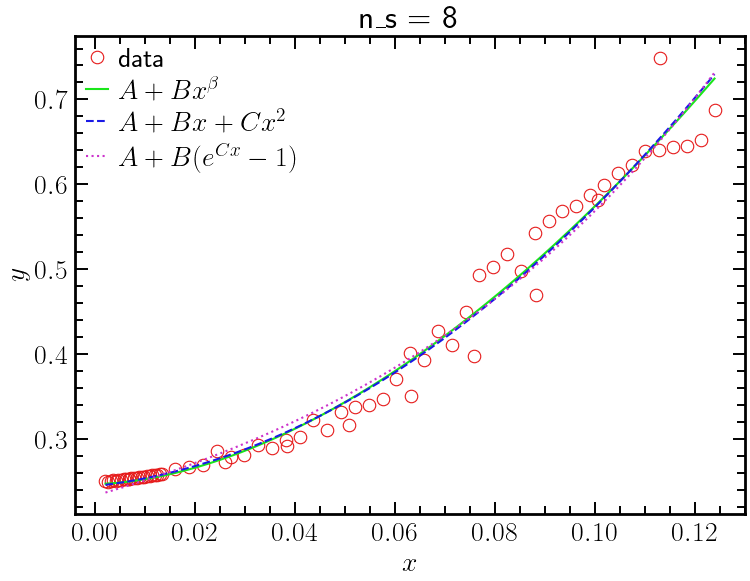

In [37]:
L_lst = [256, 512, 1024]
#L_lst = [256]
c = 0.05
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1
nc = 8
rho = 1/nc
dim = 3
f_TMAX = 0.25

L = 1024

df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & 
            (df['p0']==p0) & (df['P0']==P0) & (df['order']==1) & (df['rho']==rho) & (df['dim']==dim)].sort_values('f_T')
#df_b = df_b[df_b['f_T']<=f_TMAX]


df_plot = df_b.sort_values("f_T").copy()
df_plot = df_plot[(df_plot["p_mean"] >= 0) & (df_plot["p_mean"] <= 1)]
df_plot = df_plot[df_plot["N_samples_perc"] >= 5]
df_plot = df_plot[df_plot["p_mean"] < 0.85]  # se quiser remover regime saturado

idx = df_plot.index[df_plot["p_mean"] >= 0.85] 
if len(idx) > 0:
    idx_cut = idx[0]
    df_trunc = df_plot.loc[:idx_cut].copy()
else:
    df_trunc = df_plot.copy()

x = df_trunc['f_T'] #f_t
y = df_trunc['p_mean'] #p_t
print(y)
results = compare_fits(x, y, nc)


## Configuration

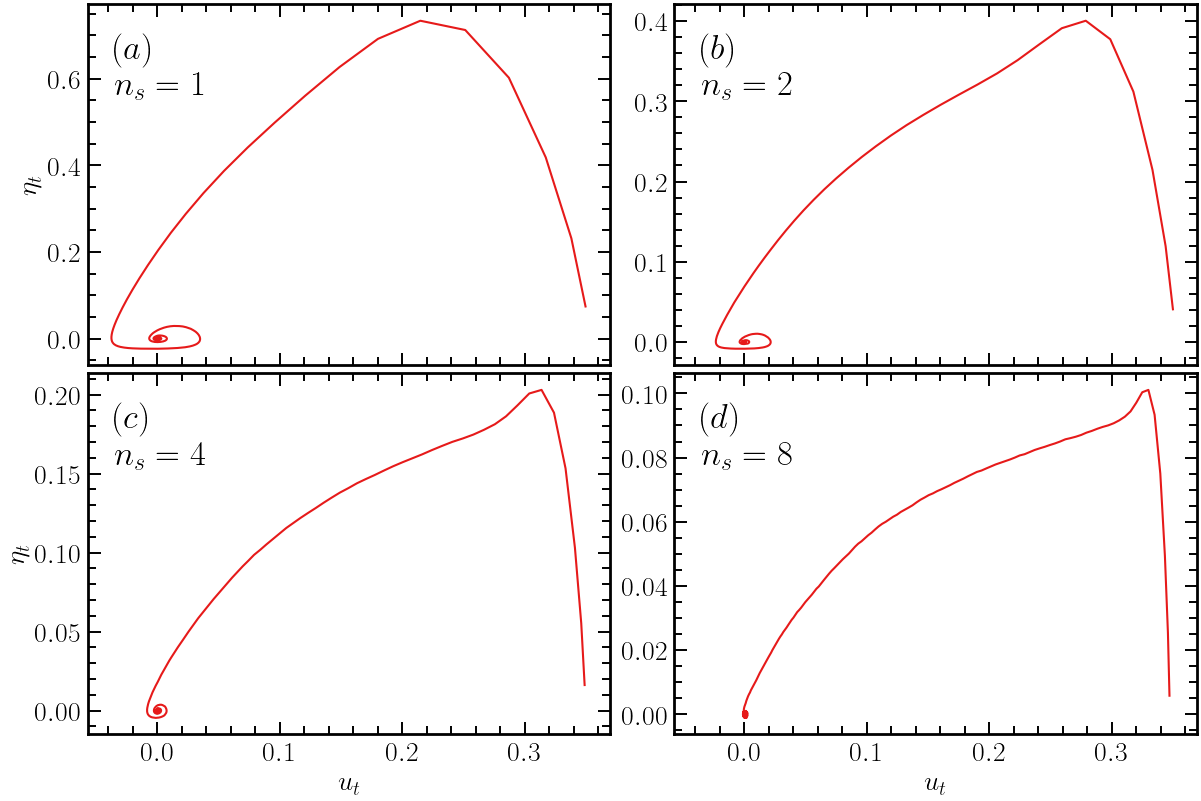

In [89]:
L = 1024
c = 0.05

p0 = 0.6
P0 = 0.1
type_perc = 'bond'
dim = 3
ns_lst  = [1,2,4,8]

def f_T(c, ns):
    if c == 0.05:
        if ns==1:
            fT = 0.02591667
        elif ns==2:
            fT = 0.009305553
        elif ns==4:
            fT = 0.008786
        elif ns==8:
            fT = 0.00671
    elif c==0.01:
        if ns==1:
            fT = 0.02591667
        elif ns==2:
            fT = 0.006710068
        elif ns==4:
            fT = 0.004114583
        elif ns==8:
            fT = 0.001519097
    return fT

p0_target = 0.6
P0_target = 0.1
figsize =  (12, 8)
fig, axes = plt.subplots(
    2, 2,
    figsize=figsize,
    constrained_layout=True,
    sharex=True
)
order_mean = 0
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',r'$(d)$']
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 30
labels_size = 35
fs_labels_fig = 25
fs_l_fig = 35
for idx, ax in enumerate(axes.flatten()):
    
    ns = ns_lst[idx]
    rho = 1/ns
    fT = f_T(c, ns)
    path = (
        f"../SOP_data/published/{type_perc}_percolation/"
        f"num_colors_{ns}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}/"
    )

    fn = "properties_mean_bundle.json"
    bundle = load_properties_bundle(path + fn)
    data = bundle[p0]["orders"][order_mean]
    time = data['time']
    p = data['pt_mean']
    f = data['ft_mean']
    p_ = data['pc_sop']['mean']
    t_stat = data['t_eq']

    t = np.array(time)
    u_t = np.array(p) - p_
    eta_t = np.array(f) - fT
    ax.plot(u_t, eta_t,)
    if(ax==axes[0,0] or ax==axes[1,0]):
        ax.set_ylabel(r'$\eta_t$')
    if(ax==axes[1,0] or ax==axes[1,1]):
        ax.set_xlabel('$u_t$')
    ax.text(0.05, 0.85, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)
    ax.text(0.05, 0.75, f"$n_s = {ns_lst[idx]}$", transform=ax.transAxes , fontsize=fs_labels_fig)
#plt.savefig(results_folder + '/configuration_all.svg')
plt.show()

In [1]:
L = 1024
c = 0.50

p0 = 0.6
P0 = 0.1
type_perc = 'bond'
dim = 3
ns_lst  = [1,2,4,8]
df_ = pd.read_csv("../SOP_data/f_T_common.csv", sep=',')

def limits(ns):
    if ns==1:
        return (-0.06, 0.06), (-0.04, 0.04)
    elif ns==2:
        return (-0.06, 0.06), (-0.02, 0.02)
    elif ns==4:
        return (-0.02, 0.02), (-0.01, 0.01)
    elif ns==8:
        return (-0.01, 0.01), (-0.04, 0.04)

p0_target = 0.6
P0_target = 0.1
figsize =  (12, 8)
fig, axes = plt.subplots(
    2, 2,
    figsize=figsize,
    constrained_layout=True
)
order_mean = 0
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',r'$(d)$']
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 30
labels_size = 35
fs_labels_fig = 25
fs_l_fig = 35
for idx, ax in enumerate(axes.flatten()):
    
    ns = ns_lst[idx]
    rho = 1/ns
    fT = df_[(df_['c']==c) & (df_['nc']==ns)]['f_T_min_common'].values[0]
    path = (
        f"../SOP_data/published/{type_perc}_percolation/"
        f"num_colors_{ns}/dim_{dim}/L_{L}/"
        f"fT_constant/fT_{fT:.6e}/"
        f"c_{c:.6e}/rho_{rho:.4e}/"
    )

    fn = "properties_mean_bundle.json"
    bundle = load_properties_bundle(path + fn)
    data = bundle[p0]["orders"][order_mean]
    time = data['time']
    p = data['pt_mean']
    f = data['ft_mean']
    p_ = data['pc_sop']['mean']
    t_stat = data['t_eq']

    t = np.array(time)
    u_t = np.array(p) - p_
    eta_t = np.array(f) - fT
    ax.plot(u_t, eta_t,)
    if(ax==axes[0,0] or ax==axes[1,0]):
        ax.set_ylabel(r'$\eta_t$')
    if(ax==axes[1,0] or ax==axes[1,1]):
        ax.set_xlabel('$u_t$')
    ax.set_xlim(*limits(ns)[0])
    ax.set_ylim(*limits(ns)[1])
    #ax.text(0.05, 0.85, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)
    #ax.text(0.05, 0.10, f"$n_s = {ns}$", transform=ax.transAxes , fontsize=fs_labels_fig)
plt.savefig(results_folder + f'/configuration_all_{c}.pdf')
plt.show()

NameError: name 'pd' is not defined

In [ ]:
import numpy as np

def fit_linear_feedback_model(
    t,
    p,
    f,
    fT,
    c,
    t_stat=None,
    p_star=None,
    tail_fraction=0.3,
    u_max=None,
    eta_max=None,
    fit_after_t_stat=False,
    min_points=10
):
    """
    Ajusta o modelo linear efetivo:

        u_{t+1} = u_t - c eta_t
        eta_{t+1} = a u_t + b eta_t

    com

        u_t = p_t - p*
        eta_t = f(t) - f_T

    Aqui c NÃO é estimado. Ele é fornecido como parâmetro de controle.

    Parameters
    ----------
    t : array
        Vetor de tempos.

    p : array
        Série temporal p(t).

    f : array
        Série temporal f(t) = N(t)/L^(d-1).

    fT : float
        Valor alvo f_T.

    c : float
        Parâmetro de controle da regra de atualização do SOP.

    t_stat : float, optional
        Tempo a partir do qual o regime estacionário é considerado.
        Usado para estimar p* se p_star não for fornecido.

    p_star : float, optional
        Valor estacionário de p. Se None, será estimado.

    tail_fraction : float
        Fração final da série usada para estimar p*, caso t_stat=None.

    u_max : float, optional
        Janela local em |u_t|.

    eta_max : float, optional
        Janela local em |eta_t|.

    fit_after_t_stat : bool
        Se True, usa apenas pontos com t >= t_stat no ajuste.

    min_points : int
        Número mínimo de pontos necessários para ajustar.

    Returns
    -------
    result : dict
        Dicionário com p_star, a, b, c, lambdas, Jacobiano e dados usados.
    """

    t = np.asarray(t, dtype=float)
    p = np.asarray(p, dtype=float)
    f = np.asarray(f, dtype=float)

    if not (len(t) == len(p) == len(f)):
        raise ValueError("t, p e f devem ter o mesmo tamanho.")

    if len(t) < 3:
        raise ValueError("A série precisa ter pelo menos 3 pontos.")

    # ------------------------------------------------------------
    # 1. Estima p*
    # ------------------------------------------------------------
    if p_star is None:
        if t_stat is not None:
            mask_stat = t >= t_stat

            if np.sum(mask_stat) < min_points:
                raise ValueError(
                    "Poucos pontos para estimar p_star com esse t_stat."
                )

            p_star = np.mean(p[mask_stat])

        else:
            n_tail = int(tail_fraction * len(p))
            n_tail = max(n_tail, min_points)

            p_star = np.mean(p[-n_tail:])

    # ------------------------------------------------------------
    # 2. Define u_t e eta_t
    # ------------------------------------------------------------
    u = p - p_star
    eta = f - fT

    # Variáveis no tempo t
    u_t = u[:-1]
    eta_t = eta[:-1]
    t_t = t[:-1]

    # Variáveis no tempo t+1
    u_next = u[1:]
    eta_next = eta[1:]

    # ------------------------------------------------------------
    # 3. Máscara para ajuste local
    # ------------------------------------------------------------
    mask = np.ones_like(u_t, dtype=bool)

    if u_max is not None:
        mask &= np.abs(u_t) <= u_max

    if eta_max is not None:
        mask &= np.abs(eta_t) <= eta_max

    if fit_after_t_stat and t_stat is not None:
        mask &= t_t >= t_stat

    n_points_fit = np.sum(mask)

    if n_points_fit < min_points:
        raise ValueError(
            f"Poucos pontos para o ajuste: {n_points_fit} pontos. "
            "Tente aumentar u_max, eta_max ou desativar fit_after_t_stat."
        )

    u_fit = u_t[mask]
    eta_fit = eta_t[mask]

    u_next_fit = u_next[mask]
    eta_next_fit = eta_next[mask]

    # ------------------------------------------------------------
    # 4. Ajusta apenas a e b:
    #
    #       eta_{t+1} = a u_t + b eta_t
    # ------------------------------------------------------------
    X_ab = np.column_stack([u_fit, eta_fit])
    y_ab = eta_next_fit

    coef_ab, *_ = np.linalg.lstsq(X_ab, y_ab, rcond=None)

    a_est = coef_ab[0]
    b_est = coef_ab[1]

    # ------------------------------------------------------------
    # 5. Usa c fornecido pelo usuário
    # ------------------------------------------------------------
    c_used = float(c)

    # ------------------------------------------------------------
    # 6. Monta o Jacobiano
    # ------------------------------------------------------------
    J = np.array([
        [1.0, -c_used],
        [a_est, b_est]
    ])

    lambdas = np.linalg.eigvals(J)

    lambda_1 = lambdas[0]
    lambda_2 = lambdas[1]

    spectral_radius = np.max(np.abs(lambdas))

    if 0 < spectral_radius < 1:
        tau = -1.0 / np.log(spectral_radius)
    else:
        tau = np.nan

    # ------------------------------------------------------------
    # 7. Predições do modelo
    # ------------------------------------------------------------
    u_next_pred = u_fit - c_used * eta_fit
    eta_next_pred = a_est * u_fit + b_est * eta_fit

    mse_u = np.mean((u_next_fit - u_next_pred)**2)
    mse_eta = np.mean((eta_next_fit - eta_next_pred)**2)

    return {
        "p_star": p_star,
        "a": a_est,
        "b": b_est,
        "c": c_used,
        "J": J,
        "lambda_1": lambda_1,
        "lambda_2": lambda_2,
        "spectral_radius": spectral_radius,
        "tau": tau,
        "mse_u": mse_u,
        "mse_eta": mse_eta,
        "n_points_fit": n_points_fit,
        "u_fit": u_fit,
        "eta_fit": eta_fit,
        "u_next_fit": u_next_fit,
        "eta_next_fit": eta_next_fit,
        "u_next_pred": u_next_pred,
        "eta_next_pred": eta_next_pred,
    }

In [92]:
res = fit_linear_feedback_model(
    t=t,
    p=p,
    f=f,
    fT=fT,
    t_stat=t_stat,
    u_max=0.03,
    eta_max=0.02,
    fit_after_t_stat=False
)

print("p* =", res["p_star"])
print("a  =", res["a"])
print("b  =", res["b"])
print("c  =", res["c"])
print("lambda_1 =", res["lambda_1"])
print("lambda_2 =", res["lambda_2"])
print("rho(J) =", res["spectral_radius"])
print("tau =", res["tau"])
print("J =")
print(res["J"])

p* = 0.24948989550826398
a  = 0.0024259383971774887
b  = 0.9892814797434863
c  = 0.009912849220344876
lambda_1 = 0.9968026158101952
lambda_2 = 0.9924788639332911
rho(J) = 0.9968026158101952
tau = 312.2553923250955
J =
[[ 1.         -0.00991285]
 [ 0.00242594  0.98928148]]


In [93]:
if res["spectral_radius"] < 1:
    print("O ponto fixo é linearmente estável.")
else:
    print("O ponto fixo é linearmente instável ou marginal.")

if np.iscomplex(res["lambda_1"]) or np.iscomplex(res["lambda_2"]):
    print("A convergência é oscilatória amortecida se |lambda| < 1.")
else:
    print("A convergência é monotônica ou alternada, dependendo do sinal dos autovalores.")

O ponto fixo é linearmente estável.
A convergência é monotônica ou alternada, dependendo do sinal dos autovalores.


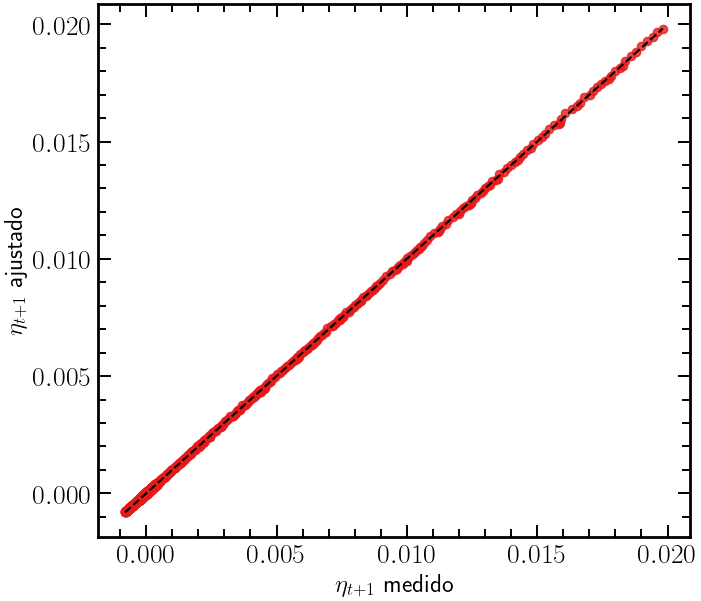

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

ax.scatter(
    res["eta_next_fit"],
    res["eta_next_pred"],
    s=35,
    alpha=0.8
)

min_val = min(np.min(res["eta_next_fit"]), np.min(res["eta_next_pred"]))
max_val = max(np.max(res["eta_next_fit"]), np.max(res["eta_next_pred"]))

ax.plot([min_val, max_val], [min_val, max_val], "--", color="black")

ax.set_xlabel(r"$\eta_{t+1}$ medido", fontsize=18)
ax.set_ylabel(r"$\eta_{t+1}$ ajustado", fontsize=18)
#plt.savefig('teste.pdf')
plt.show()

In [95]:
import numpy as np
import matplotlib.pyplot as plt


def plot_linear_feedback_fit(res, figsize=(18, 5), fs=18):
    """
    Plota a comparação entre dados e ajuste do modelo linear:

        u_{t+1} = u_t - c eta_t
        eta_{t+1} = a u_t + b eta_t

    A função espera o dicionário `res` retornado por fit_linear_feedback_model().
    """

    u_t = np.asarray(res["u_fit"])
    eta_t = np.asarray(res["eta_fit"])

    u_next = np.asarray(res["u_next_fit"])
    eta_next = np.asarray(res["eta_next_fit"])

    u_next_pred = np.asarray(res["u_next_pred"])
    eta_next_pred = np.asarray(res["eta_next_pred"])

    a = res["a"]
    b = res["b"]
    c = res["c"]

    lambda_1 = res["lambda_1"]
    lambda_2 = res["lambda_2"]
    rho = res["spectral_radius"]

    idx = np.arange(len(u_t))

    fig, axes = plt.subplots(
        1, 3,
        figsize=figsize,
        constrained_layout=True
    )

    # ------------------------------------------------------------
    # 1. eta_{t+1}: medido versus ajustado
    # ------------------------------------------------------------
    ax = axes[0]

    ax.plot(
        idx,
        eta_next,
        "o",
        ms=6,
        alpha=0.75,
        label=r"$\eta_{t+1}$ medido"
    )

    ax.plot(
        idx,
        eta_next_pred,
        "-",
        lw=2.5,
        label=r"$\eta_{t+1}=a u_t+b\eta_t$"
    )

    ax.set_xlabel("índice dos pontos usados no ajuste", fontsize=fs)
    ax.set_ylabel(r"$\eta_{t+1}$", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs-4)
    ax.legend(fontsize=fs-5)

    # ------------------------------------------------------------
    # 2. u_{t+1}: medido versus ajustado
    # ------------------------------------------------------------
    ax = axes[1]

    ax.plot(
        idx,
        u_next,
        "o",
        ms=6,
        alpha=0.75,
        label=r"$u_{t+1}$ medido"
    )

    ax.plot(
        idx,
        u_next_pred,
        "-",
        lw=2.5,
        label=r"$u_{t+1}=u_t-c\eta_t$"
    )

    ax.set_xlabel("índice dos pontos usados no ajuste", fontsize=fs)
    ax.set_ylabel(r"$u_{t+1}$", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs-4)
    ax.legend(fontsize=fs-5)

    # ------------------------------------------------------------
    # 3. Plano de fase: trajetória observada versus predita
    # ------------------------------------------------------------
    ax = axes[2]

    ax.plot(
        u_t,
        eta_t,
        "o-",
        ms=5,
        lw=1.5,
        alpha=0.65,
        label="dados"
    )

    ax.plot(
        u_next_pred,
        eta_next_pred,
        "s-",
        ms=5,
        lw=2.0,
        alpha=0.85,
        label="fit linear"
    )

    ax.axhline(0.0, ls="--", lw=1.2, color="black")
    ax.axvline(0.0, ls="--", lw=1.2, color="black")

    ax.set_xlabel(r"$u_t=p_t-p^\ast$", fontsize=fs)
    ax.set_ylabel(r"$\eta_t=f(t)-f_T$", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs-4)
    ax.legend(fontsize=fs-5)

    title = (
        rf"$a={a:.4g}$, $b={b:.4g}$, $c={c:.4g}$"
        "\n"
        rf"$\lambda_1={lambda_1:.4g}$, "
        rf"$\lambda_2={lambda_2:.4g}$, "
        rf"$\rho(J)={rho:.4g}$"
    )

    fig.suptitle(title, fontsize=fs)

    plt.show()

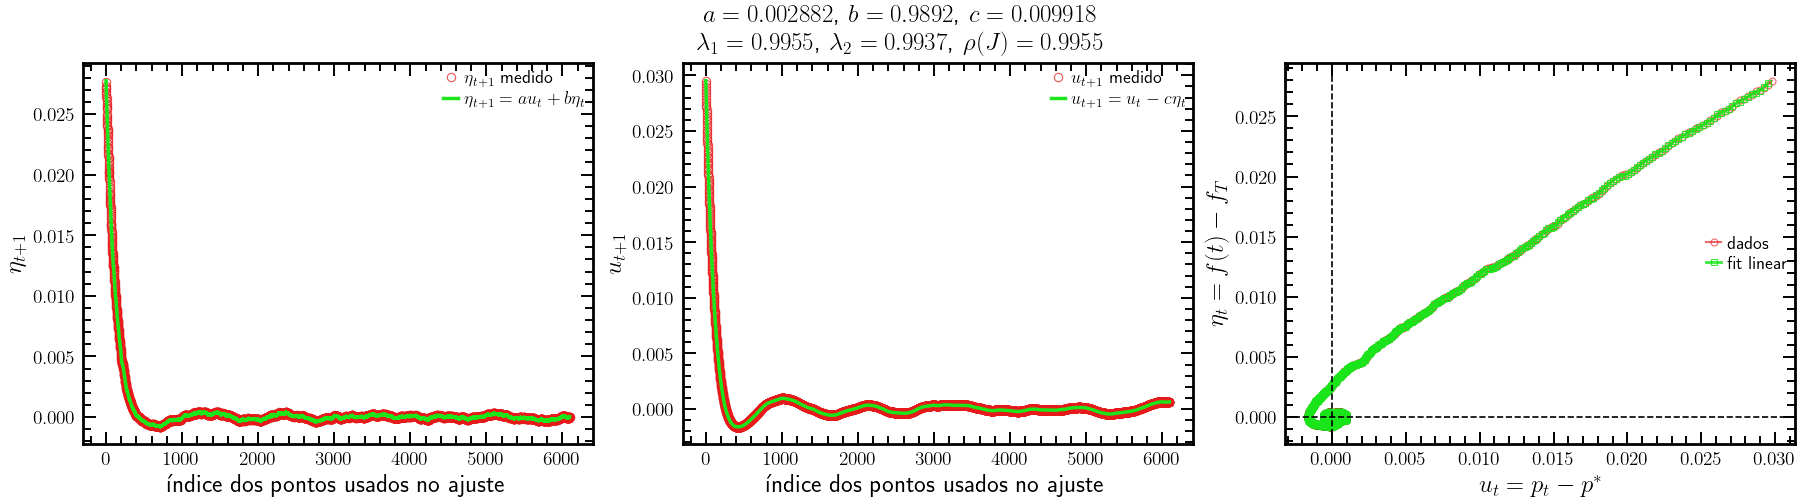

In [96]:
res = fit_linear_feedback_model(
    t=t,
    p=p,
    f=f,
    fT=fT,
    t_stat=t_stat,
    u_max=0.03,
    eta_max=0.03,
    fit_after_t_stat=False
)

plot_linear_feedback_fit(res)